**STOCASTIC GRADIENT DESCENT**

While Batch Gradient Descent looks at the entire dataset to take a single step, Stochastic Gradient Descent (SGD) takes a step after looking at just one random training example.

**The problem with Batch GD**

Suppose if you have 10 million rows, Batch GD must calculate the error for all 10 million rows before it can update the weights once. This makes it incredibly slow for "Big Data." And the entire training data should be loaded into the RAM which is costly.

**SGD**

SGD updates the weights after every single row. It starts learning immediately. we only need to load one row of data into RAM at a time. Because it only looks at one point, the "path" to the minimum is noisy and zig-zags. This "noise" is actually helpful because it can help the model jump out of shallow local minima to find a better global one.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

diabetes = datasets.load_diabetes()
X = diabetes.data
y = diabetes.target.reshape(-1, 1)
X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

n_samples, n_features = X_std.shape
weights = np.zeros((n_features, 1))
bias = 0
learning_rate = 0.001
epochs = 50 

loss_history = []

for epoch in range(epochs):
    indices = np.random.permutation(n_samples)
    X_shuffled = X_std[indices]
    y_shuffled = y[indices]
    
    epoch_loss = 0
    
    for i in range(n_samples):
        xi = X_shuffled[i:i+1] 
        yi = y_shuffled[i:i+1] 
        
        y_pred = np.dot(xi, weights) + bias
        error = y_pred - yi
        
        dw = 2 * xi.T.dot(error)
        db = 2 * error
        
        weights -= learning_rate * dw
        bias -= learning_rate * db
        
        epoch_loss += error**2
    
    loss_history.append(epoch_loss[0][0] / n_samples)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss {loss_history[-1]:.4f}")

print("Training Complete.")

Epoch 0: Loss 14684.3845
Epoch 10: Loss 2934.8071
Epoch 20: Loss 2930.4617
Epoch 30: Loss 2909.3284
Epoch 40: Loss 2920.6808
Training Complete.


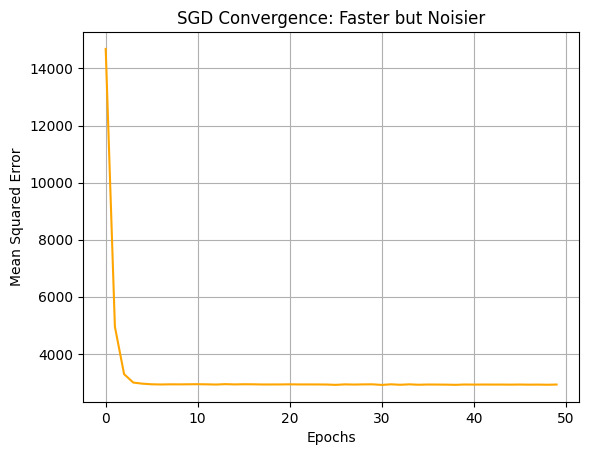

In [5]:
plt.plot(range(epochs), loss_history, color='orange')
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("SGD Convergence: Faster but Noisier")
plt.grid(True)
plt.show()